### Supervised Learning (Classification Problem)

In [1]:
### importing packages
import pandas as pd
import matplotlib.pyplot as plt ## for visualization
import seaborn as sns ## for visualization


from sklearn.preprocessing import LabelEncoder ## convert binary categorical to numeric
from sklearn.model_selection import train_test_split ## to divide the data set into train and test data
from sklearn.preprocessing import StandardScaler ## to standardize the continuous feature

from imblearn.over_sampling import SMOTE ## Synthetic Minority OVersampling Technique
from collections import Counter ## Check how many of each class we are using for the training

from sklearn.linear_model import LogisticRegression ## logistic regression
from sklearn.tree import DecisionTreeClassifier ## Decision tree
from sklearn.ensemble import RandomForestClassifier ## Random Forest
from sklearn.svm import SVC ## Support Vector Classifier
from xgboost import XGBClassifier  ## xgboost
## pip install xgboost ## You need to first install xgboost

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import joblib ## to save our model for deployment

import warnings
warnings.filterwarnings("ignore") ## to  suppress warning output

In [84]:
### Load data set 
bc = pd.read_csv("BankChurners.csv")

### Data preprocessing
- This entails data cleaning, and correcting any anomalies

In [85]:
### Display the first 5
bc.head()

,Client_num,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [86]:
### check the shape
bc.shape

(10127, 21)

In [87]:
### overview of the data
bc.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client_num                10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  str    
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  str    
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  str    
 6   Marital_Status            10127 non-null  str    
 7   Income_Category           10127 non-null  str    
 8   Card_Category             10127 non-null  str    
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_Revolving_B

In [88]:
### checking data types
bc.dtypes

Client_num                    int64
Attrition_Flag                  str
Customer_Age                  int64
Gender                          str
Dependent_count               int64
Education_Level                 str
Marital_Status                  str
Income_Category                 str
Card_Category                   str
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object

In [89]:
#### check for missing values
bc.isna().sum()

Client_num                  0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

In [90]:
### check for duplicates, using client_num as primary key
bc.duplicated(subset = "Client_num").sum()

np.int64(0)

In [91]:
## To know the number of unique entries 
bc["Dependent_count"].nunique()

6

In [92]:
### list comprehension - categorical features
cat_features = [item for item in bc.columns if bc[item].dtype == "object" or bc[item].nunique()<10]

In [93]:
print(cat_features)

['Attrition_Flag', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon']


In [94]:
#### list comprehension - numeric features
numeric_features = [item for item in bc.columns if item not in cat_features]

In [95]:
### summary statistics from the categorical features
bc[cat_features].describe(include = "object").T

,count,unique,top,freq
Attrition_Flag,10127,2,Existing Customer,8500
Gender,10127,2,F,5358
Education_Level,10127,7,Graduate,3128
Marital_Status,10127,4,Married,4687
Income_Category,10127,6,Less than $40K,3561
Card_Category,10127,4,Blue,9436


In [96]:
### summary statistics from the numeric features / continuous variables
bc[numeric_features].describe()

,Client_num,Customer_Age,Months_on_book,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,35.928409,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,7.986416,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,13.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,31.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,36.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,40.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,56.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


#### Check multicollinearity using the correlation cofficient
- 1: Perfect correlation
- 0.9 - 0.7: strong correlation
- 0.6 - 0.4: moderate correlation
- 0.3 - 0.1: weak correlation
- 0: No correlation

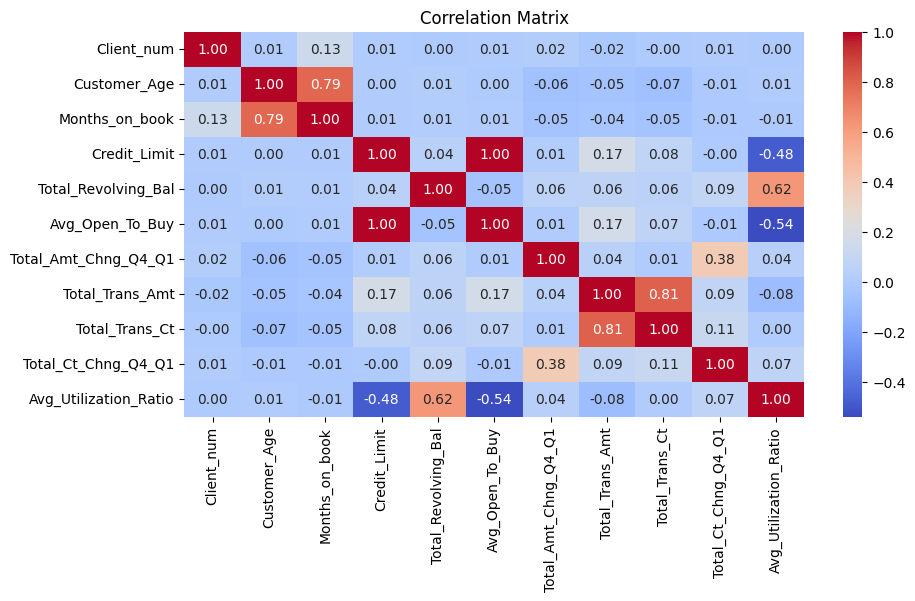

In [97]:
### correlation of numeric features
plt.figure(figsize = (10,5))
sns.heatmap(bc[numeric_features].corr(), annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Matrix")
plt.show()

#### Since there is a perfect correlation between credit limit and avg_open to buy,this is a clear issue of multicollinearity. This means that we will have drop one. Avg_open to buy relies on credit, hence avg_open to buy will be dropped

### Check for outliers 

In [98]:
#### IQR = Q3 - Q1
#### outliers below the minimum threshold = Q1 - 1.5*IQR
#### outliers above the maximum threshold = Q3 + 1.5*IQR
for item in numeric_features:
    Q1 = bc[item].quantile(0.25)
    Q3 = bc[item].quantile(0.75)
    IQR = Q3 - Q1
    min_threshold = Q1 - 1.5*IQR
    max_threshold = Q3 + 1.5*IQR
    outliers = bc[(bc[item]<min_threshold) | (bc[item]>max_threshold)]
    print(f"{item} :{len(outliers)} outliers")

Client_num :0 outliers
Customer_Age :2 outliers
Months_on_book :386 outliers
Credit_Limit :984 outliers
Total_Revolving_Bal :0 outliers
Avg_Open_To_Buy :963 outliers
Total_Amt_Chng_Q4_Q1 :396 outliers
Total_Trans_Amt :896 outliers
Total_Trans_Ct :2 outliers
Total_Ct_Chng_Q4_Q1 :394 outliers
Avg_Utilization_Ratio :0 outliers


In [99]:
bc.head(2)

,Client_num,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105


In [100]:
### converting the categorical variables to numeric variables
bc["Attrition_Flag"].unique()

<ArrowStringArray>
['Existing Customer', 'Attrited Customer']
Length: 2, dtype: str

In [101]:
## Initialize the LabelEncoder
le = LabelEncoder()
bc["Gender"] = le.fit_transform(bc["Gender"]) # uses alphabetical order

In [102]:
#### converting our target variable to numeric values
y = le.fit_transform(bc["Attrition_Flag"])

In [105]:
bc['Gender'].dtype

dtype('int64')

In [82]:
#### one-hot encoding
hot_var = [item for item in cat_features if item not in ["Attrition_Flag", "Gender"] and bc[item].dtypes == "object"]
#cat_features

In [81]:
print(hot_var)

[]


In [77]:
### convert the categorical columns to dummies
bc_dummies = pd.get_dummies(bc, columns = hot_var, drop_first = True)

In [78]:
### shape of the original table
bc.shape

(10127, 21)

In [79]:
### shape of the new table after converting to dummy variable
bc_dummies.shape

(10127, 21)

In [26]:
### checking the columns of the new table
bc_dummies.columns

Index(['Client_num', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='str')

### Feature Engineering

In [27]:
### select the features
X = bc_dummies.drop(["Attrition_Flag", "Avg_Open_To_Buy", "Client_num"], axis = 1)

In [28]:
#### Split the data into train and test data. Train data will be 80% and test will be 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

In [29]:
### Initialize the standard scaler
scaler = StandardScaler()

In [30]:
### Excluding client_num and Avg_Open_To_Buy from the numeric features list
for i in ["Client_num", "Avg_Open_To_Buy"]:
    numeric_features.remove(i)
print(numeric_features)

['Customer_Age', 'Months_on_book', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


In [31]:
### standardizing the numeric features
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

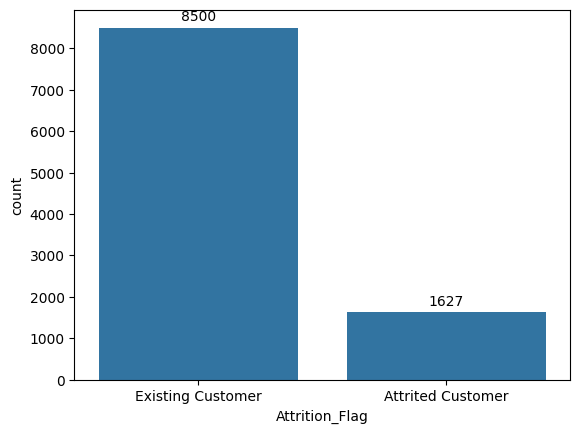

In [32]:
#### checking the distribution of the target variable
ax = sns.countplot(x = bc["Attrition_Flag"])
for item in ax.containers:
    ax.bar_label(item, fmt = "%d", padding = 3)
plt.show()

In [33]:
## check how many data points of Attrited customers and Existing customers is used in traning the dataset
print(Counter(y_train))

Counter({np.int64(1): 6799, np.int64(0): 1302})


In [34]:
## Initialize SMOTE
smote = SMOTE()

In [35]:
## resample the train data using SMOTE
X_train, y_train = smote.fit_resample(X_train, y_train)

ValueError: could not convert string to float: 'College'

In [42]:
Counter(y_train)

Counter({np.int64(0): 6799, np.int64(1): 6799})

### Logistic Regression

In [43]:
### Initialize the model
model_log = LogisticRegression(random_state = 42)

In [44]:
### Traning the machine
model_log.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [45]:
### Using the model for prediction
y_pred = model_log.predict(X_test)

### Model Evaluation

In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.71      0.64       325
           1       0.94      0.90      0.92      1701

    accuracy                           0.87      2026
   macro avg       0.76      0.81      0.78      2026
weighted avg       0.88      0.87      0.88      2026



In [50]:
#precision = TP/(TP+FP)
precision_1 = 1535/(1535+95)
print(precision_1)

#precision_0 = TN/(TN+FN)
precision_0 = 230/(230+166)
print(precision_0)

recall = 1535/(1535+166)
print(recall)


0.941717791411043
0.5808080808080808
0.9024103468547913


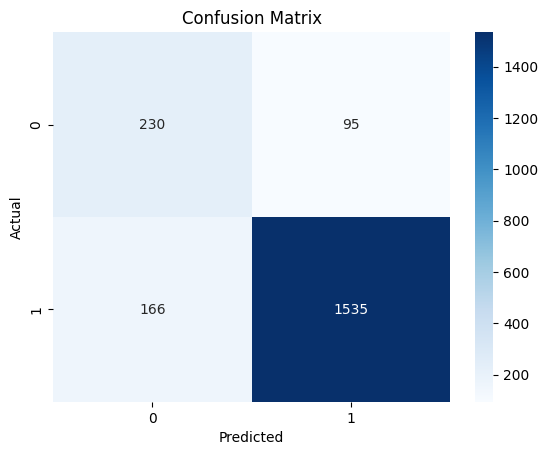

In [47]:
cm_log = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_log, annot = True, fmt = "d", cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Decision Tree

In [51]:
### Initialize the decision tree 
mod_dt = DecisionTreeClassifier(random_state = 42)

In [52]:
### Training the model
mod_dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [53]:
### Using the model for prediction
y_pred_dt = mod_dt.predict(X_test)

### Evaluating Decision Tree Model

In [54]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.71      0.86      0.78       325
           1       0.97      0.93      0.95      1701

    accuracy                           0.92      2026
   macro avg       0.84      0.90      0.87      2026
weighted avg       0.93      0.92      0.92      2026



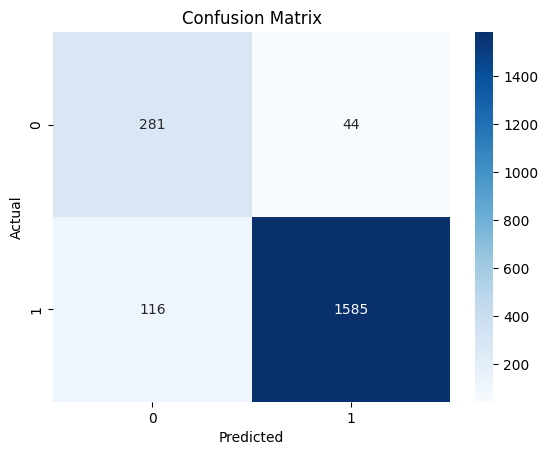

In [55]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot = True, fmt = "d", cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### Random Forest 

In [56]:
### Initialize the random forest
mod_rf = RandomForestClassifier(random_state = 42)

In [57]:
## Train the model
mod_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [58]:
### Test the model
y_pred_rf = mod_rf.predict(X_test)

### Evaluating the Random Forest

In [59]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       325
           1       0.98      0.97      0.98      1701

    accuracy                           0.96      2026
   macro avg       0.92      0.94      0.93      2026
weighted avg       0.96      0.96      0.96      2026



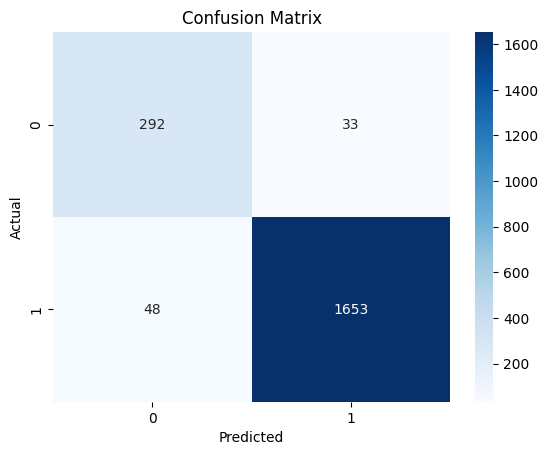

In [60]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot = True, fmt = "d", cmap = "Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Support Vector Classifier

In [61]:
### Initialize the SVC 
mod_svc = SVC(random_state = 42)

In [62]:
### Train the model
mod_svc.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [63]:
### predict with the model
y_pred_svc = mod_svc.predict(X_test)

In [64]:
### Evaluate the model
print(classification_report(y_test, y_pred_svc))

              precision    recall  f1-score   support

           0       0.71      0.83      0.76       325
           1       0.97      0.93      0.95      1701

    accuracy                           0.92      2026
   macro avg       0.84      0.88      0.86      2026
weighted avg       0.92      0.92      0.92      2026



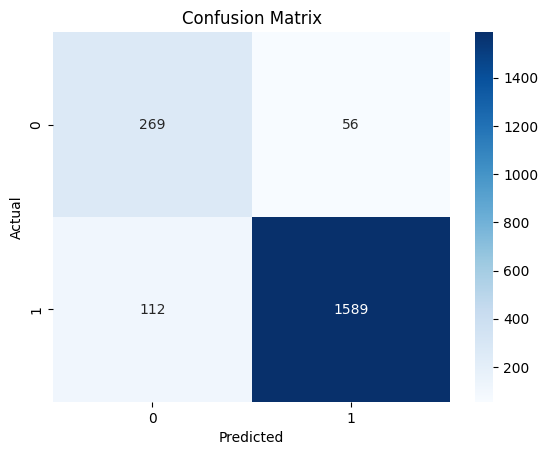

In [65]:
### visualize the confusion matrix
cm_svc = confusion_matrix(y_test, y_pred_svc)
sns.heatmap(cm_svc, annot = True, fmt = "d", cmap = "Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### XGBoost Classifier

In [66]:
mod_xgb = XGBClassifier(learning_rate = 0.1, max_depth = 5, random_state = 42, n_estimators = 100)

In [67]:
### Train the model
mod_xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [68]:
### predict with the model
y_pred_xgb = mod_xgb.predict(X_test)

In [69]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.86      0.93      0.89       325
           1       0.99      0.97      0.98      1701

    accuracy                           0.96      2026
   macro avg       0.92      0.95      0.94      2026
weighted avg       0.97      0.96      0.97      2026



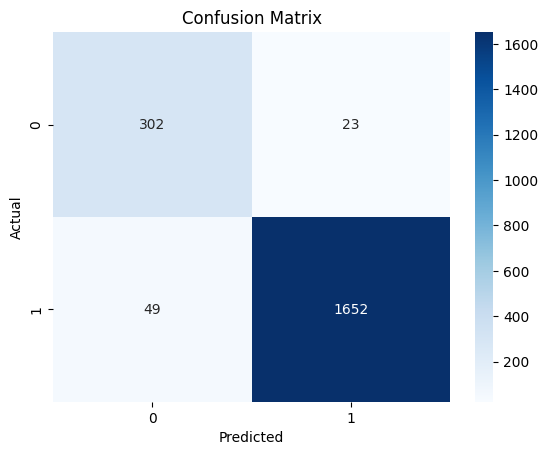

In [70]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot = True, fmt = "d", cmap = "Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Selecting the best model
- We used five different algorithms. Out of these, `xgboost` gave the better accuracy, precision, and recall for both classes
- This means our preferred model for deployment is `xgboost`

### save the trained or selected model

In [71]:
joblib.dump(mod_xgb, "bank_churn_model.joblib")

['bank_churn_model.joblib']